# Part 2

In [11]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
from scipy.io import loadmat
from scipy.ndimage import convolve1d


import seaborn as sns
sns.set()
import re



plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120

### Load the data

Import and list all files

In [8]:
# Path to folder containing the 27 MAT files
DATA_DIR = "./data"   # change if needed, e.g. "/data" on the VM

# Find all .mat files in the folder
mat_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".mat")]
)

print(f"Found {len(mat_files)} .mat files in {DATA_DIR}:")
for f in mat_files:
    print("  ", f)


Found 27 .mat files in ./data:
   S10_A1_E1.mat
   S11_A1_E1.mat
   S12_A1_E1.mat
   S13_A1_E1.mat
   S14_A1_E1.mat
   S15_A1_E1.mat
   S16_A1_E1.mat
   S17_A1_E1.mat
   S18_A1_E1.mat
   S19_A1_E1.mat
   S1_A1_E1.mat
   S20_A1_E1.mat
   S21_A1_E1.mat
   S22_A1_E1.mat
   S23_A1_E1.mat
   S24_A1_E1.mat
   S25_A1_E1.mat
   S26_A1_E1.mat
   S27_A1_E1.mat
   S2_A1_E1.mat
   S3_A1_E1.mat
   S4_A1_E1.mat
   S5_A1_E1.mat
   S6_A1_E1.mat
   S7_A1_E1.mat
   S8_A1_E1.mat
   S9_A1_E1.mat


Store in one datastructure but keep easily separable for followings tasks

`subjects` is a list where each entry is a dictionary with the following keys:

- **subject_id** → integer like `1, 2, 3, ...`
- **filename** → original `.mat` filename
- **emg** → array of shape `(n_samples, 10)` containing the EMG data
- **stimulus** → array of shape `(n_samples,)` with integer labels  
  (`0 = rest`, `1–12 = movement classes`)
- **repetition** → array of shape `(n_samples,)` with repetition indices  
  (`0 = none`, `1–10 = actual repetition`)

In [42]:
subjects = []

for fname in mat_files:
    path = os.path.join(DATA_DIR, fname)
    data = loadmat(path)
    
    # Extract variables in the same way as Exercise 11
    emg = data["emg"]                    # shape (T, 10)
    stimulus = data["restimulus"]        # shape (T, 1) or (T,)
    repetition = data["rerepetition"]    # shape (T, 1) or (T,)

    # squeeze to 1D vectors for convenience
    stimulus = np.squeeze(stimulus).astype(int)
    repetition = np.squeeze(repetition).astype(int)
    
    # Parse subject ID from filename, e.g. "S12_A1_E1.mat" -> 12
    m = re.search(r"S(\d+)_A1_E1\.mat", fname, re.IGNORECASE)
    if m:
        subject_id = int(m.group(1))
    else:
        subject_id = len(subjects) + 1

    subjects.append(
        {
            "subject_id": subject_id,
            "filename": fname,
            "emg": emg,
            "stimulus": stimulus,
            "repetition": repetition,
        }
    )

# 🔹 NEW: sort subjects by true subject_id (1..27)
subjects = sorted(subjects, key=lambda s: s["subject_id"])

print(f"Loaded {len(subjects)} subjects.")

# Quick sanity print
for subj in subjects:
    emg = subj["emg"]
    print(
        f"Subject {subj['subject_id']:2d} ({subj['filename']}): "
        f"EMG shape = {emg.shape}, "
        f"unique stimuli = {np.unique(subj['stimulus']).size - 1}, "
        f"unique reps = {np.unique(subj['repetition']).size - 1}"
    )

print(f"Loaded {len(subjects)} subjects.")

# Quick sanity print
for subj in subjects:
    emg = subj["emg"]
    print(
        f"Subject {subj['subject_id']:2d} ({subj['filename']}): "
        f"EMG shape = {emg.shape}, "
        f"unique stimuli = {np.unique(subj['stimulus']).size - 1}, "
        f"unique reps = {np.unique(subj['repetition']).size - 1}"
    )


Loaded 27 subjects.
Subject  1 (S1_A1_E1.mat): EMG shape = (101014, 10), unique stimuli = 12, unique reps = 10
Subject  2 (S2_A1_E1.mat): EMG shape = (100686, 10), unique stimuli = 12, unique reps = 10
Subject  3 (S3_A1_E1.mat): EMG shape = (100720, 10), unique stimuli = 12, unique reps = 10
Subject  4 (S4_A1_E1.mat): EMG shape = (100835, 10), unique stimuli = 12, unique reps = 10
Subject  5 (S5_A1_E1.mat): EMG shape = (100894, 10), unique stimuli = 12, unique reps = 10
Subject  6 (S6_A1_E1.mat): EMG shape = (101083, 10), unique stimuli = 12, unique reps = 10
Subject  7 (S7_A1_E1.mat): EMG shape = (100817, 10), unique stimuli = 12, unique reps = 10
Subject  8 (S8_A1_E1.mat): EMG shape = (100854, 10), unique stimuli = 12, unique reps = 10
Subject  9 (S9_A1_E1.mat): EMG shape = (100925, 10), unique stimuli = 12, unique reps = 10
Subject 10 (S10_A1_E1.mat): EMG shape = (100778, 10), unique stimuli = 12, unique reps = 10
Subject 11 (S11_A1_E1.mat): EMG shape = (100899, 10), unique stimuli 

## 1. Consider now 27 subjects (only exercise set 1 as in part 1). Perform the same preprocessing pipeline as in part 1.  

For each channel the mean (over stimulus and repetition), including STD and mean envelope. For one subject only here

In [48]:
# Sampling frequency as in Part 1 (Ninapro DB2)
fs = 100  

# Moving-average envelope (same as Exercises / Part 1)
mov_mean_length  = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

def plot_mean_curves_per_channel(subject_id):
    """
    For a given subject:
      - build trials for all (stimulus, repetition) pairs (excluding rest = 0)
      - truncate to common length
      - compute per-channel:
          * mean EMG curve over trials
          * std EMG curve over trials
          * mean envelope curve over trials
      - plot one figure per channel
    """
    # --- find subject ---
    matches = [s for s in subjects if s["subject_id"] == subject_id]
    if not matches:
        print(f"No subject with ID {subject_id} found.")
        return
    subj = matches[0]
    
    emg       = subj["emg"]          # (T, 10)
    stimulus  = subj["stimulus"]     # (T,)
    repetition = subj["repetition"]  # (T,)
    
    n_channels = emg.shape[1]
    
    # use only real movements (exclude rest = 0)
    stim_vals = np.unique(stimulus)
    stim_vals = stim_vals[stim_vals > 0]
    rep_vals  = np.unique(repetition)
    rep_vals  = rep_vals[rep_vals > 0]
    
    # ---------- 1st pass: determine common trial length ----------
    trial_lengths = []
    for s_id in stim_vals:
        for r_id in rep_vals:
            idx = (stimulus == s_id) & (repetition == r_id)
            L = np.sum(idx)
            if L > 0:
                trial_lengths.append(L)
    if not trial_lengths:
        print("No trials found for this subject.")
        return
    
    min_len = int(np.min(trial_lengths))
    print(f"Subject {subject_id}: using common trial length {min_len} samples "
          f"({min_len / fs:.2f} s)")
    
    # ---------- 2nd pass: collect truncated trials ----------
    all_trials_emg = []   # list of arrays (min_len, n_channels)
    all_trials_env = []   # same
    
    for s_id in stim_vals:
        for r_id in rep_vals:
            idx = (stimulus == s_id) & (repetition == r_id)
            if not np.any(idx):
                continue
            trial = emg[idx, :]              # (L, 10)
            trial = trial[:min_len, :]       # truncate
            env   = convolve1d(trial, mov_mean_weights, axis=0)
            env   = env[:min_len, :]
            
            all_trials_emg.append(trial)
            all_trials_env.append(env)
    
    all_trials_emg = np.stack(all_trials_emg, axis=0)  # (n_trials, min_len, n_channels)
    all_trials_env = np.stack(all_trials_env, axis=0)  # (n_trials, min_len, n_channels)
    
    n_trials = all_trials_emg.shape[0]
    print(f"Collected {n_trials} trials.")
    
    # time axis
    t = np.arange(min_len) / fs
    
    # ---------- plot one figure per channel ----------
    for ch in range(n_channels):
        emg_ch = all_trials_emg[:, :, ch]   # (n_trials, min_len)
        env_ch = all_trials_env[:, :, ch]
        
        mean_emg = emg_ch.mean(axis=0)
        std_emg  = emg_ch.std(axis=0)
        mean_env = env_ch.mean(axis=0)
        
        plt.figure(figsize=(8, 4))
        
        # mean EMG ± std
        plt.fill_between(
            t,
            mean_emg - std_emg,
            mean_emg + std_emg,
            alpha=0.3,
            label="Mean EMG ± std"
        )
        # mean EMG curve
        plt.plot(t, mean_emg, label="Mean EMG")
        # mean envelope curve
        plt.plot(t, mean_env, linestyle="--", label="Mean envelope")
        
        plt.title(f"Subject {subject_id} – Channel {ch+1}")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


Subject 1: using common trial length 184 samples (1.84 s)
Collected 120 trials.


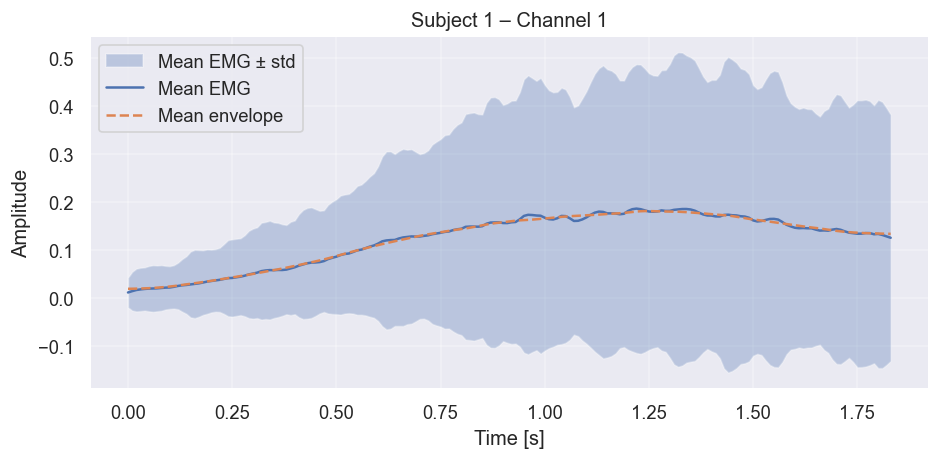

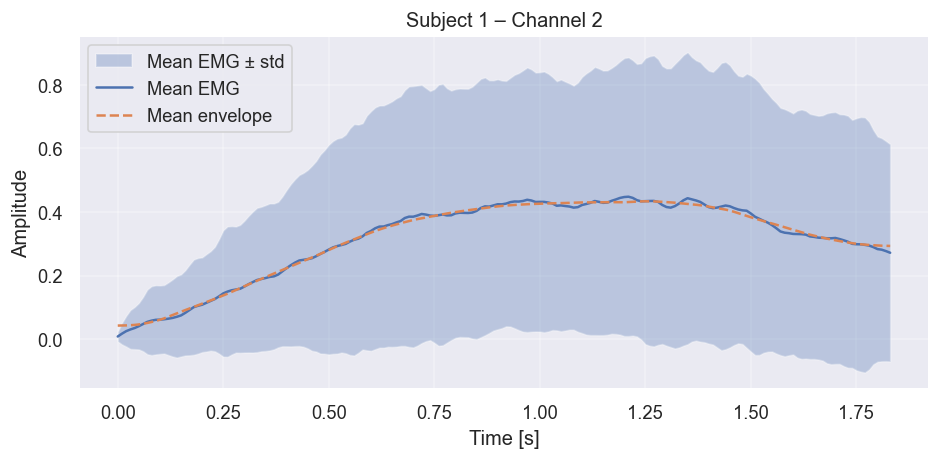

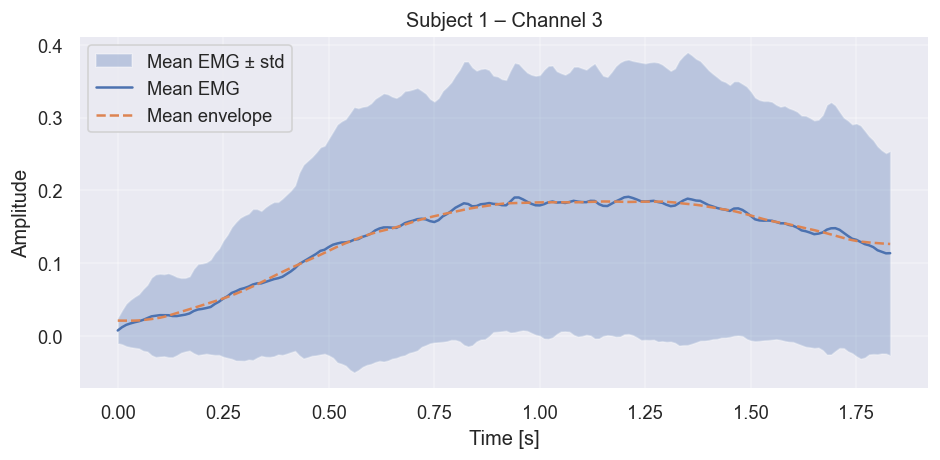

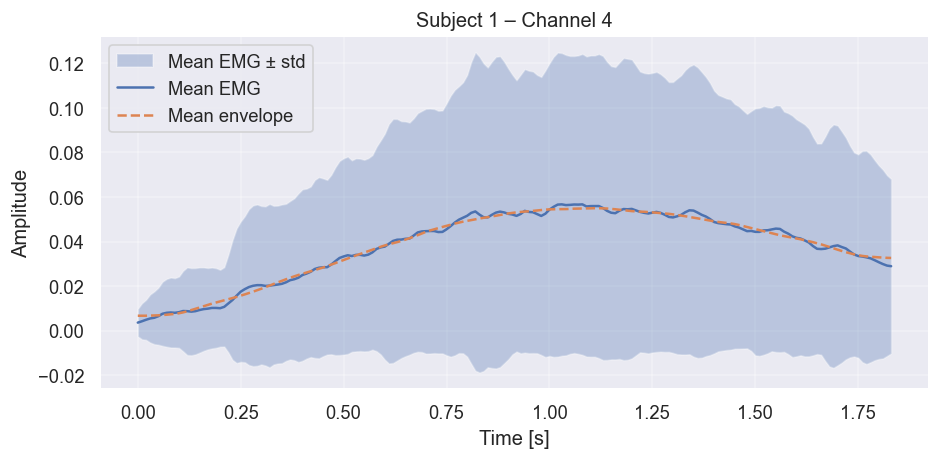

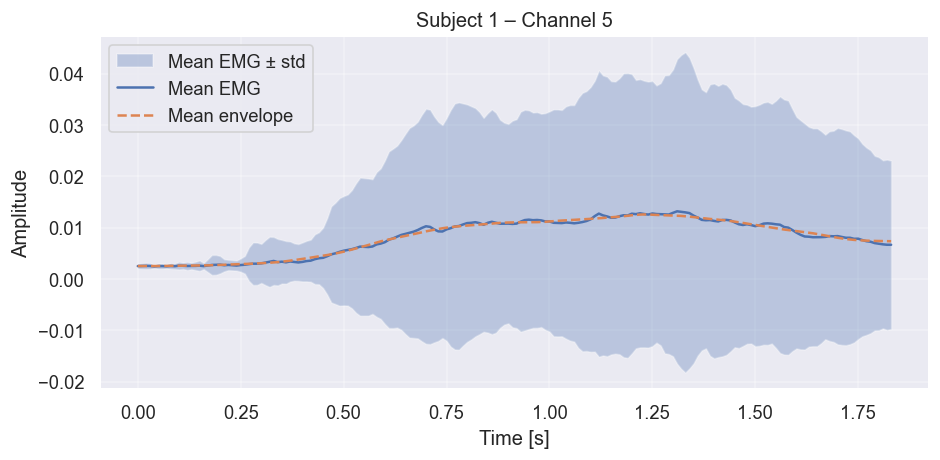

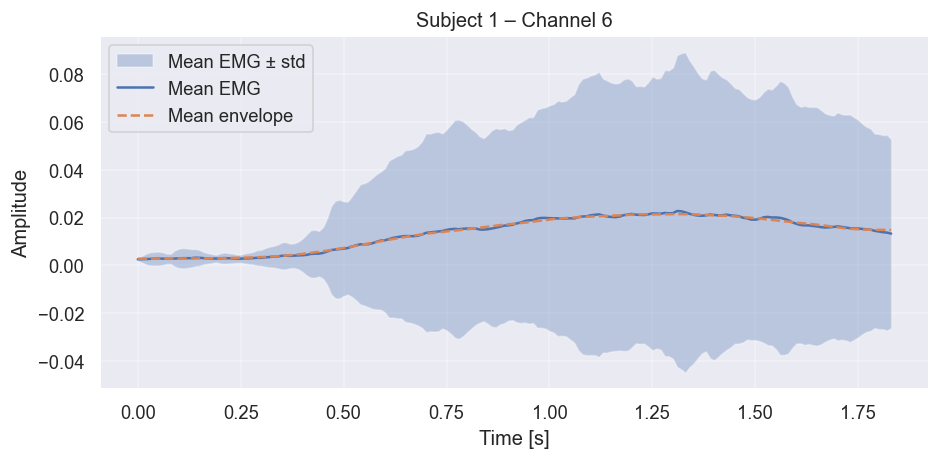

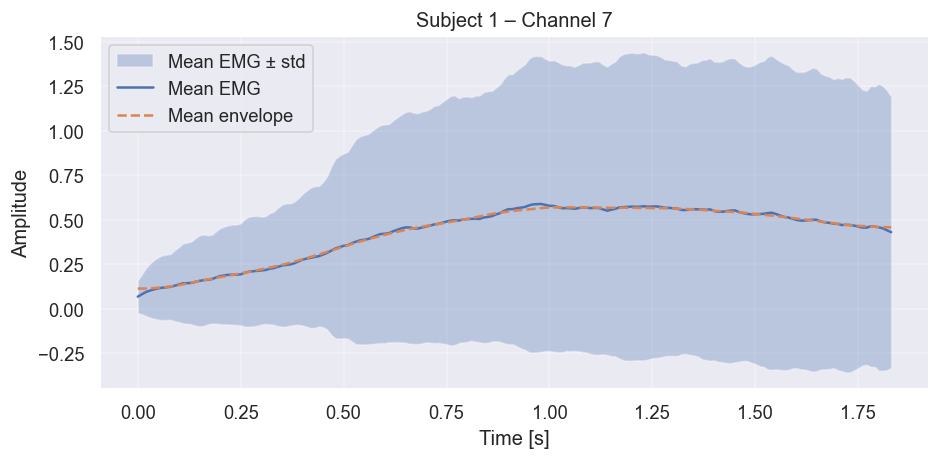

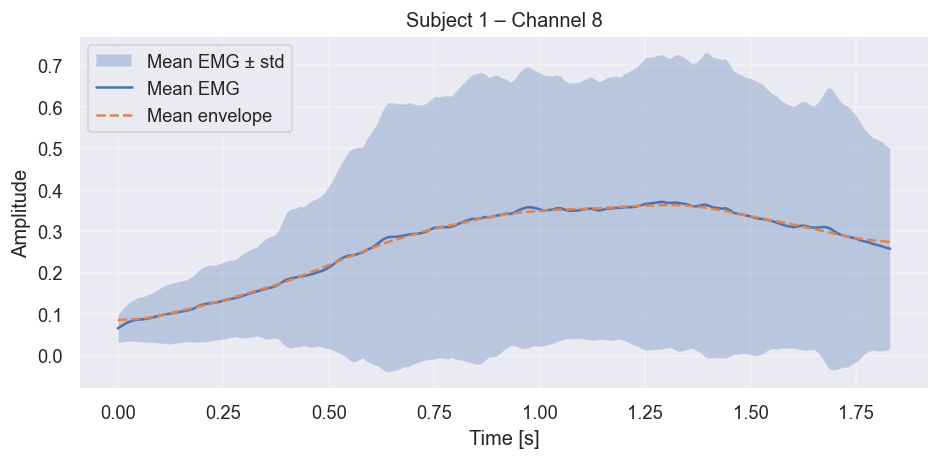

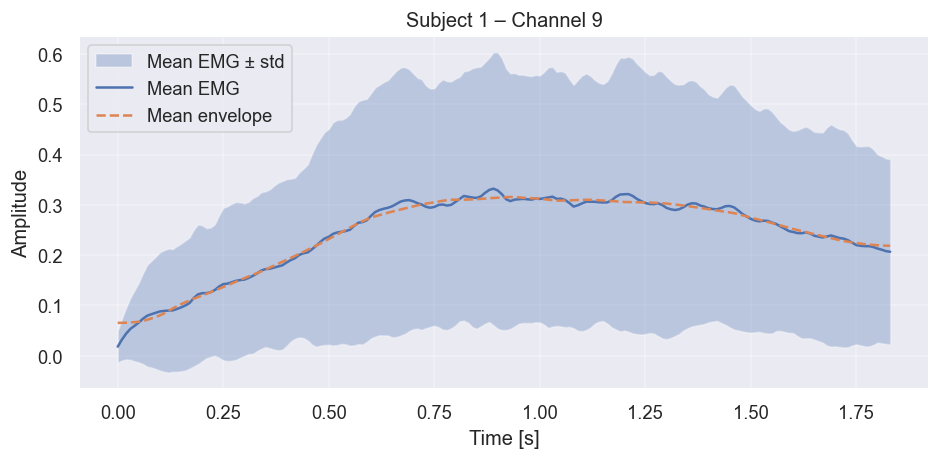

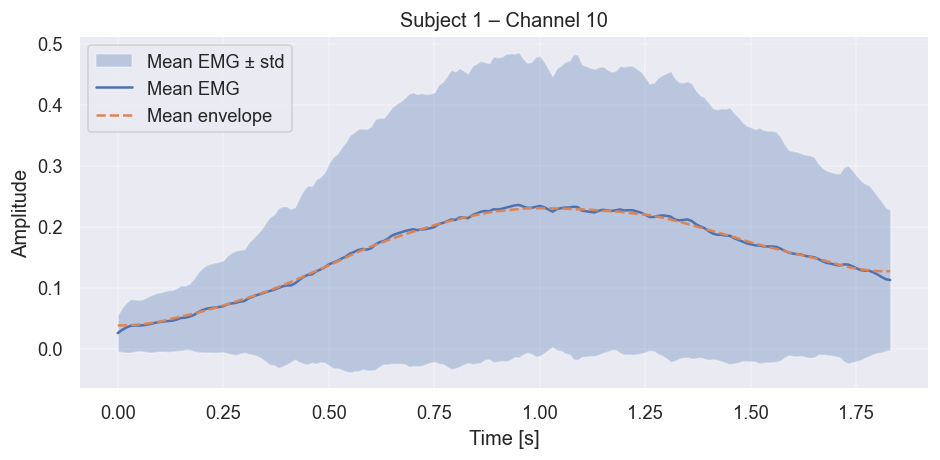

In [49]:
plot_mean_curves_per_channel(subject_id=1)


Maybe something went wrong but there are negative values

<span style="color: red;">Check for negative values TODO.</span>


In [43]:
# Same envelope parameters as in Exercises / Part 1
mov_mean_length  = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

def plot_trial_emg_and_envelope(subject_id, stimulus_id, repetition_id):
    """
    Visualize one trial (all channels) for a given subject.
    All arguments are 1-based labels, matching Ninapro:

    - subject_id: 1..27
    - stimulus_id: 1..12   (0 = rest is ignored)
    - repetition_id: 1..10 (0 = none)
    """

    # --- pick subject by true subject_id (1..27) ---
    matches = [s for s in subjects if s["subject_id"] == subject_id]
    if not matches:
        print(f"No subject with ID {subject_id} found.")
        return
    subj = matches[0]

    emg = subj["emg"]
    stimulus = subj["stimulus"]
    repetition = subj["repetition"]

    # basic sanity checks on labels
    if stimulus_id not in np.unique(stimulus):
        print(f"Stimulus ID {stimulus_id} not found for subject {subject_id}.")
        return
    if repetition_id not in np.unique(repetition):
        print(f"Repetition ID {repetition_id} not found for subject {subject_id}.")
        return

    # select the trial using 1-based labels directly
    idx = (stimulus == stimulus_id) & (repetition == repetition_id)
    if not np.any(idx):
        print(
            f"No samples for subject {subject_id}, "
            f"stimulus {stimulus_id}, repetition {repetition_id}."
        )
        return

    trial = emg[idx, :]              # (T_trial, n_channels)
    env   = convolve1d(trial, mov_mean_weights, axis=0)

    n_channels = trial.shape[1]

    fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True, sharex=True)
    ax = ax.ravel()

    for ch in range(n_channels):
        ax[ch].plot(trial[:, ch], color="lightgray",
                    label="EMG" if ch == 0 else None)
        ax[ch].plot(env[:, ch], color="black",
                    label="Envelope" if ch == 0 else None)
        ax[ch].set_title(f"Channel {ch+1}")   # 1-based channel label

    # hide unused subplots if needed
    for k in range(n_channels, len(ax)):
        ax[k].axis("off")

    if n_channels > 0:
        ax[0].legend()

    plt.suptitle(
        f"Subject {subject_id}, stimulus {stimulus_id}, repetition {repetition_id}\n"
        "EMG (gray) and envelope (black)",
        y=1.02
    )

    plt.show()


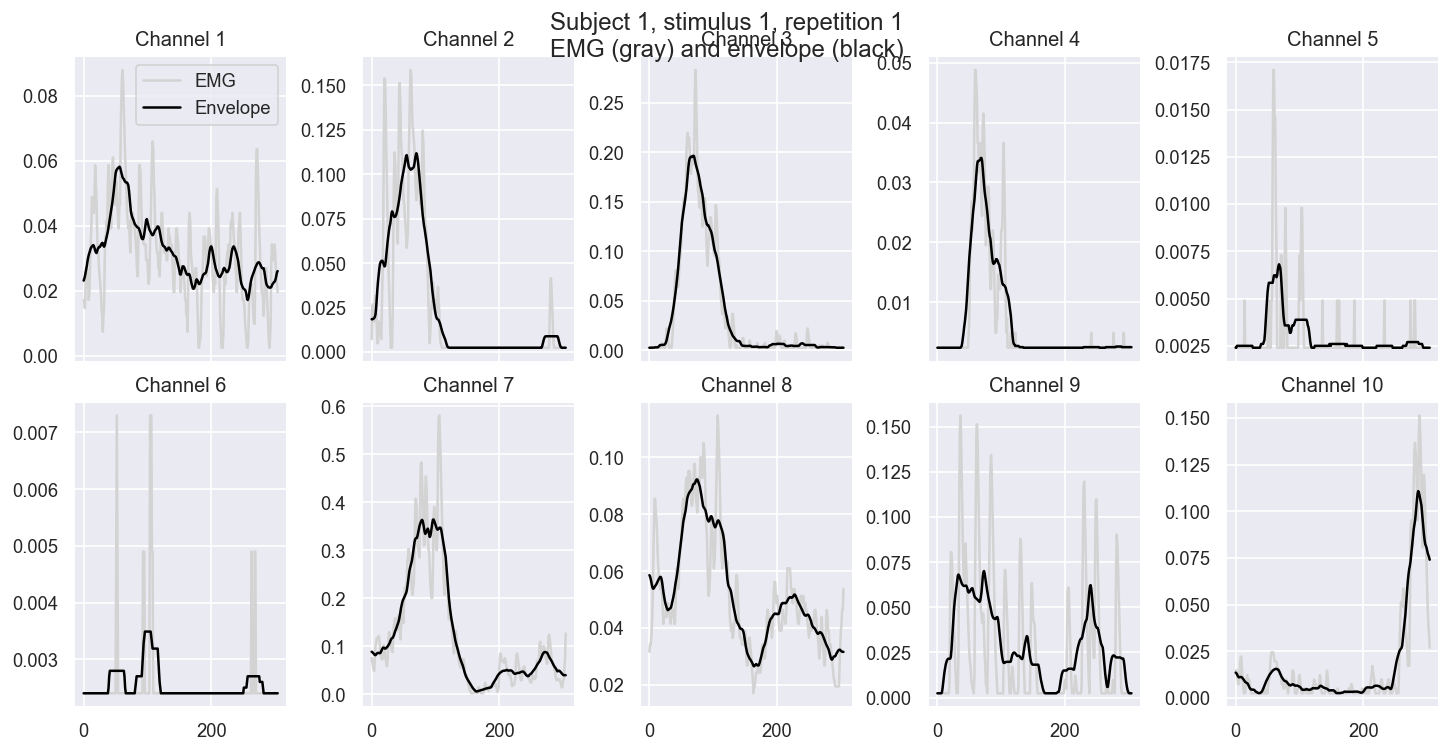

In [47]:
# Subject 1, stimulus 1, repetition 1 (all 1-based labels)
plot_trial_emg_and_envelope(subject_id=1, stimulus_id=1, repetition_id=1)


Automatic flagging (similar to part 1)

In [56]:
def find_bad_trials(
    signal, 
    restimulus, 
    rerepetition, 
    actions, 
    reps, 
    rms_drop_fraction=0.1, 
    min_std=1e-7
):
    """
    Flag (action, repetition) trials where one or more channels are basically 'dead'.
    SAME AS PART 1, except:
        - bad_channels in output are now 1-based instead of 0-based.
    """

    bad_trials = []

    # Global RMS per channel over the full recording
    global_rms = np.sqrt(np.mean(signal**2, axis=0))

    for a in actions:
        for r in reps:
            idx = (restimulus == a) & (rerepetition == r)
            trial = signal[idx, :]
            if trial.size == 0:
                continue

            # Trial-level RMS and std per channel
            trial_rms = np.sqrt(np.mean(trial**2, axis=0))
            trial_std = trial.std(axis=0)

            # Conditions for 'bad' channels
            low_amp = trial_rms < (rms_drop_fraction * global_rms)
            flat    = trial_std < min_std

            # still compute channels 0-based
            bad_ch = np.where(low_amp | flat)[0]

            if len(bad_ch) > 0:

                # 🔹 convert from 0-based → 1-based for OUTPUT ONLY
                bad_ch_1based = (bad_ch + 1).tolist()

                bad_trials.append({
                    "action": int(a),          # already 1-based
                    "repetition": int(r),      # already 1-based
                    "bad_channels": bad_ch_1based,
                    "trial_length": int(trial.shape[0])
                })

    return bad_trials


In [69]:
subject_id = 3  # true subject number, 1..27

# find subject dict by ID
subj = next(s for s in subjects if s["subject_id"] == subject_id)

emg_subj   = subj["emg"]
stim_subj  = subj["stimulus"]
reps_subj  = subj["repetition"]

# unique non-rest actions and non-zero reps for THIS subject only
actions_subj = np.unique(stim_subj)
actions_subj = actions_subj[actions_subj > 0]

unique_reps_subj = np.unique(reps_subj)
unique_reps_subj = unique_reps_subj[unique_reps_subj > 0]

bad_trials_subj = find_bad_trials(
    signal=emg_subj,
    restimulus=stim_subj,
    rerepetition=reps_subj,
    actions=actions_subj,
    reps=unique_reps_subj,
    rms_drop_fraction=0.005,   # same as Part 1 call
    min_std=1e-7
)

print(f"Subject {subject_id} – suspicious trials: {len(bad_trials_subj)}")
bad_trials_subj[:10]



Subject 3 – suspicious trials: 3


[{'action': 2, 'repetition': 7, 'bad_channels': [6], 'trial_length': 266},
 {'action': 2, 'repetition': 10, 'bad_channels': [6], 'trial_length': 355},
 {'action': 3, 'repetition': 10, 'bad_channels': [2], 'trial_length': 531}]

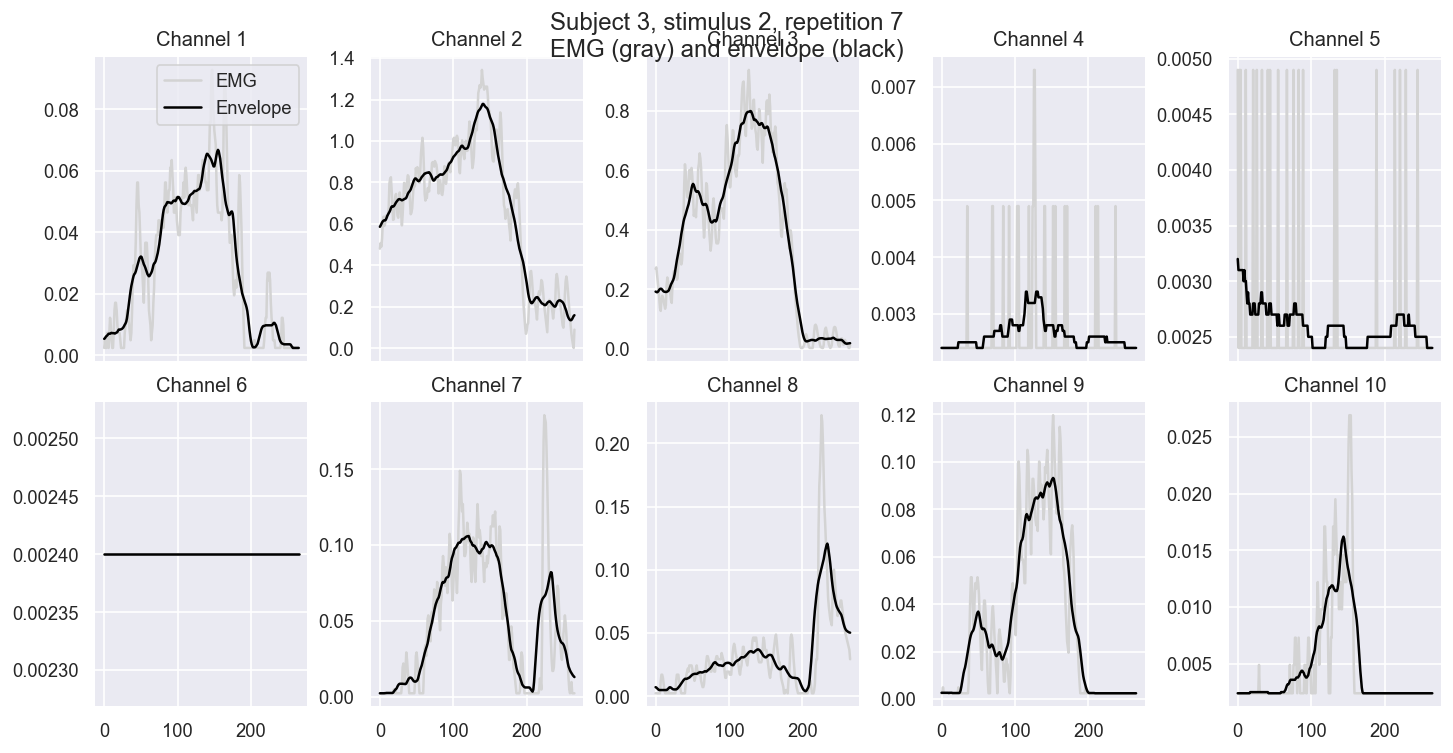

In [70]:
plot_trial_emg_and_envelope(subject_id=3, stimulus_id=2, repetition_id=7)


Loop over subjects

In [66]:
all_bad_trials = {}   # subject_id → list of bad trials

for subj in subjects:   # subjects is already sorted by subject_id
    sid = subj["subject_id"]

    emg_subj = subj["emg"]
    stim_subj = subj["stimulus"]
    reps_subj = subj["repetition"]

    # Unique non-rest actions and non-zero reps for THIS subject
    actions_subj = np.unique(stim_subj)
    actions_subj = actions_subj[actions_subj > 0]

    reps_unique_subj = np.unique(reps_subj)
    reps_unique_subj = reps_unique_subj[reps_unique_subj > 0]

    # Run Part-1 logic
    bad_trials = find_bad_trials(
        signal=emg_subj,
        restimulus=stim_subj,
        rerepetition=reps_subj,
        actions=actions_subj,
        reps=reps_unique_subj,
        rms_drop_fraction=0.005,  # same as your Part 1 setting
        min_std=1e-7
    )

    all_bad_trials[sid] = bad_trials

    # Nice formatted printout
    if len(bad_trials) == 0:
        print(f"Subject {sid:2d}: OK (no suspicious trials)")
    else:
        bad_ch_all = sorted({ch for trial in bad_trials for ch in trial['bad_channels']})
        print(
            f"Subject {sid:2d}: {len(bad_trials):2d} suspicious trials – "
            f"bad channels (1-based): {bad_ch_all}"
        )


Subject  1: 12 suspicious trials – bad channels (1-based): [2, 4, 6]
Subject  2: OK (no suspicious trials)
Subject  3:  3 suspicious trials – bad channels (1-based): [2, 6]
Subject  4: OK (no suspicious trials)
Subject  5: OK (no suspicious trials)
Subject  6: OK (no suspicious trials)
Subject  7:  2 suspicious trials – bad channels (1-based): [2]
Subject  8: OK (no suspicious trials)
Subject  9:  7 suspicious trials – bad channels (1-based): [2, 4, 6]
Subject 10: OK (no suspicious trials)
Subject 11:  1 suspicious trials – bad channels (1-based): [9]
Subject 12:  9 suspicious trials – bad channels (1-based): [6]
Subject 13:  4 suspicious trials – bad channels (1-based): [2, 4]
Subject 14: OK (no suspicious trials)
Subject 15: OK (no suspicious trials)
Subject 16:  1 suspicious trials – bad channels (1-based): [4, 6]
Subject 17: OK (no suspicious trials)
Subject 18:  5 suspicious trials – bad channels (1-based): [4, 6, 9]
Subject 19: 32 suspicious trials – bad channels (1-based): [4, 5

In [68]:
print("\n=== Full Detailed Output for All Subjects ===\n")

for subj in subjects:
    sid = subj["subject_id"]

    emg_subj  = subj["emg"]
    stim_subj = subj["stimulus"]
    reps_subj = subj["repetition"]

    # Extract valid movements and repetitions
    actions_subj = np.unique(stim_subj)
    actions_subj = actions_subj[actions_subj > 0]

    reps_unique_subj = np.unique(reps_subj)
    reps_unique_subj = reps_unique_subj[reps_unique_subj > 0]

    # Run your updated Part-1 logic
    bad_trials_subj = find_bad_trials(
        signal=emg_subj,
        restimulus=stim_subj,
        rerepetition=reps_subj,
        actions=actions_subj,
        reps=reps_unique_subj,
        rms_drop_fraction=0.005,
        min_std=1e-7
    )

    print(f"\n--- Subject {sid} ---")
    print(f"Found {len(bad_trials_subj)} suspicious trials")

    if len(bad_trials_subj) == 0:
        continue

    # Print the full list of trials, exactly like individual call
    for entry in bad_trials_subj:
        print(entry)



=== Full Detailed Output for All Subjects ===


--- Subject 1 ---
Found 12 suspicious trials
{'action': 2, 'repetition': 3, 'bad_channels': [4], 'trial_length': 233}
{'action': 2, 'repetition': 4, 'bad_channels': [6], 'trial_length': 234}
{'action': 2, 'repetition': 9, 'bad_channels': [6], 'trial_length': 229}
{'action': 11, 'repetition': 2, 'bad_channels': [6], 'trial_length': 285}
{'action': 11, 'repetition': 6, 'bad_channels': [6], 'trial_length': 240}
{'action': 11, 'repetition': 9, 'bad_channels': [6], 'trial_length': 238}
{'action': 12, 'repetition': 4, 'bad_channels': [6], 'trial_length': 239}
{'action': 12, 'repetition': 5, 'bad_channels': [2], 'trial_length': 526}
{'action': 12, 'repetition': 6, 'bad_channels': [4], 'trial_length': 261}
{'action': 12, 'repetition': 7, 'bad_channels': [4], 'trial_length': 185}
{'action': 12, 'repetition': 8, 'bad_channels': [4, 6], 'trial_length': 521}
{'action': 12, 'repetition': 9, 'bad_channels': [4], 'trial_length': 224}

--- Subject 2 ---

## 2. Extract the same set of features. Now look at the values of those features across the different subjects. Are there any similarity/discrepancies between the subjects?  